In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import plotly.express as px
import json
import re

In [2]:
#flying squirrels data 
flying_squirrels = gpd.read_file('data/HBF_85817_geo_u (1).gpkg')

flying_squirrels = flying_squirrels[::-1].reset_index(drop=True)

#filter flying squirrel observations after 2000
flying_squirrels_2000 = flying_squirrels[flying_squirrels['year'] >= 2000]
flying_squirrels_2000

#flying_squirrels_2000['year'] = flying_squirrels_2000['year'].astype(str)

#flying_squirrels_2000['formatted_date_time'] = pd.to_datetime(flying_squirrels_2000['formatted_date_time'])
#flying_squirrels_2000['date'] = flying_squirrels_2000['formatted_date_time'].dt.strftime('%d.%m.%Y')

,taxonomic_order,formatted_taxon_name,abundance_verbatim,formatted_date_time,country,bio_province_interpreted,locality,collection_name,team,year,geometry
1239,64441,Siberian Flying Squirrel — Pteromys volans,9,2000-01-01,Suomi,"Etelä-Häme (EH), Etelä-Karjala (EK), Etelä-Sav...",NaN,Wildlife triangle,NaN,2000,POINT (26.54583 60.65919)
1240,64441,Siberian Flying Squirrel — Pteromys volans,5,2000-01-01,Suomi,"Etelä-Häme (EH), Uusimaa (U)",NaN,Wildlife triangle,NaN,2000,POINT (25.63133 60.65297)
1241,64441,Siberian Flying Squirrel — Pteromys volans,11,2000-01-01,Suomi,"Etelä-Häme (EH), Uusimaa (U), Varsinais-Suomi (V)",NaN,Wildlife triangle,NaN,2000,POINT (24.71744 60.64051)
1242,64441,Siberian Flying Squirrel — Pteromys volans,4,2000-01-01,Suomi,Uusimaa (U),NaN,Wildlife triangle,NaN,2000,POINT (25.65002 60.20418)
1243,64441,Siberian Flying Squirrel — Pteromys volans,4,2000-01-01,Suomi,"Uusimaa (U), Varsinais-Suomi (V)",NaN,Wildlife triangle,NaN,2000,POINT (23.84819 60.17359)
...,...,...,...,...,...,...,...,...,...,...,...
9969,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-13 [12:07-12:07],Suomi,Uusimaa (U),NaN,"Lajitietokeskus/FinBIF - Notebook, general obs...",Otso Häärä,2024,POINT (24.93557 60.29196)
9970,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-20,Suomi,Uusimaa (U),NaN,Löydös Open Finnish Observation Database,Kristiina Boström-Förström,2024,POINT (22.97703 59.77408)
9971,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-20,Suomi,Uusimaa (U),NaN,Löydös Open Finnish Observation Database,kristiina boström-förström,2024,POINT (22.97703 59.77408)
9972,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-20,Suomi,Uusimaa (U),"Eläintarhan koirapuisto, Töölö",Löydös Open Finnish Observation Database,NaN,2024,POINT (25.01864 60.11016)


In [3]:
#flying squirrel data: convert dates to datetime
def extract_date_only(s):
    if not isinstance(s, str):
        return s
    match = re.search(r'\d{4}-\d{2}-\d{2}', s)
    if match:
        return match.group(0)
    return s  # fallback if no match
    
flying_squirrels_2000['clean_date_str'] = flying_squirrels_2000['formatted_date_time'].apply(extract_date_only)
flying_squirrels_2000['clean_date'] = pd.to_datetime(flying_squirrels_2000['clean_date_str'], errors='coerce')
flying_squirrels_2000['date'] = flying_squirrels_2000['clean_date'].dt.strftime('%d.%m.%Y')
flying_squirrels_2000['Observation date'] = flying_squirrels_2000['date']
flying_squirrels_2000

,taxonomic_order,formatted_taxon_name,abundance_verbatim,formatted_date_time,country,bio_province_interpreted,locality,collection_name,team,year,geometry,clean_date_str,clean_date,date,Observation date
1239,64441,Siberian Flying Squirrel — Pteromys volans,9,2000-01-01,Suomi,"Etelä-Häme (EH), Etelä-Karjala (EK), Etelä-Sav...",NaN,Wildlife triangle,NaN,2000,POINT (26.54583 60.65919),2000-01-01,2000-01-01,01.01.2000,01.01.2000
1240,64441,Siberian Flying Squirrel — Pteromys volans,5,2000-01-01,Suomi,"Etelä-Häme (EH), Uusimaa (U)",NaN,Wildlife triangle,NaN,2000,POINT (25.63133 60.65297),2000-01-01,2000-01-01,01.01.2000,01.01.2000
1241,64441,Siberian Flying Squirrel — Pteromys volans,11,2000-01-01,Suomi,"Etelä-Häme (EH), Uusimaa (U), Varsinais-Suomi (V)",NaN,Wildlife triangle,NaN,2000,POINT (24.71744 60.64051),2000-01-01,2000-01-01,01.01.2000,01.01.2000
1242,64441,Siberian Flying Squirrel — Pteromys volans,4,2000-01-01,Suomi,Uusimaa (U),NaN,Wildlife triangle,NaN,2000,POINT (25.65002 60.20418),2000-01-01,2000-01-01,01.01.2000,01.01.2000
1243,64441,Siberian Flying Squirrel — Pteromys volans,4,2000-01-01,Suomi,"Uusimaa (U), Varsinais-Suomi (V)",NaN,Wildlife triangle,NaN,2000,POINT (23.84819 60.17359),2000-01-01,2000-01-01,01.01.2000,01.01.2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9969,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-13 [12:07-12:07],Suomi,Uusimaa (U),NaN,"Lajitietokeskus/FinBIF - Notebook, general obs...",Otso Häärä,2024,POINT (24.93557 60.29196),2024-03-13,2024-03-13,13.03.2024,13.03.2024
9970,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-20,Suomi,Uusimaa (U),NaN,Löydös Open Finnish Observation Database,Kristiina Boström-Förström,2024,POINT (22.97703 59.77408),2024-03-20,2024-03-20,20.03.2024,20.03.2024
9971,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-20,Suomi,Uusimaa (U),NaN,Löydös Open Finnish Observation Database,kristiina boström-förström,2024,POINT (22.97703 59.77408),2024-03-20,2024-03-20,20.03.2024,20.03.2024
9972,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-20,Suomi,Uusimaa (U),"Eläintarhan koirapuisto, Töölö",Löydös Open Finnish Observation Database,NaN,2024,POINT (25.01864 60.11016),2024-03-20,2024-03-20,20.03.2024,20.03.2024


In [4]:
#extract observation month to its own column
flying_squirrels_2000['month'] = flying_squirrels_2000['clean_date'].dt.month
flying_squirrels_2000

,taxonomic_order,formatted_taxon_name,abundance_verbatim,formatted_date_time,country,bio_province_interpreted,locality,collection_name,team,year,geometry,clean_date_str,clean_date,date,Observation date,month
1239,64441,Siberian Flying Squirrel — Pteromys volans,9,2000-01-01,Suomi,"Etelä-Häme (EH), Etelä-Karjala (EK), Etelä-Sav...",NaN,Wildlife triangle,NaN,2000,POINT (26.54583 60.65919),2000-01-01,2000-01-01,01.01.2000,01.01.2000,1
1240,64441,Siberian Flying Squirrel — Pteromys volans,5,2000-01-01,Suomi,"Etelä-Häme (EH), Uusimaa (U)",NaN,Wildlife triangle,NaN,2000,POINT (25.63133 60.65297),2000-01-01,2000-01-01,01.01.2000,01.01.2000,1
1241,64441,Siberian Flying Squirrel — Pteromys volans,11,2000-01-01,Suomi,"Etelä-Häme (EH), Uusimaa (U), Varsinais-Suomi (V)",NaN,Wildlife triangle,NaN,2000,POINT (24.71744 60.64051),2000-01-01,2000-01-01,01.01.2000,01.01.2000,1
1242,64441,Siberian Flying Squirrel — Pteromys volans,4,2000-01-01,Suomi,Uusimaa (U),NaN,Wildlife triangle,NaN,2000,POINT (25.65002 60.20418),2000-01-01,2000-01-01,01.01.2000,01.01.2000,1
1243,64441,Siberian Flying Squirrel — Pteromys volans,4,2000-01-01,Suomi,"Uusimaa (U), Varsinais-Suomi (V)",NaN,Wildlife triangle,NaN,2000,POINT (23.84819 60.17359),2000-01-01,2000-01-01,01.01.2000,01.01.2000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9969,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-13 [12:07-12:07],Suomi,Uusimaa (U),NaN,"Lajitietokeskus/FinBIF - Notebook, general obs...",Otso Häärä,2024,POINT (24.93557 60.29196),2024-03-13,2024-03-13,13.03.2024,13.03.2024,3
9970,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-20,Suomi,Uusimaa (U),NaN,Löydös Open Finnish Observation Database,Kristiina Boström-Förström,2024,POINT (22.97703 59.77408),2024-03-20,2024-03-20,20.03.2024,20.03.2024,3
9971,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-20,Suomi,Uusimaa (U),NaN,Löydös Open Finnish Observation Database,kristiina boström-förström,2024,POINT (22.97703 59.77408),2024-03-20,2024-03-20,20.03.2024,20.03.2024,3
9972,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-20,Suomi,Uusimaa (U),"Eläintarhan koirapuisto, Töölö",Löydös Open Finnish Observation Database,NaN,2024,POINT (25.01864 60.11016),2024-03-20,2024-03-20,20.03.2024,20.03.2024,3


0


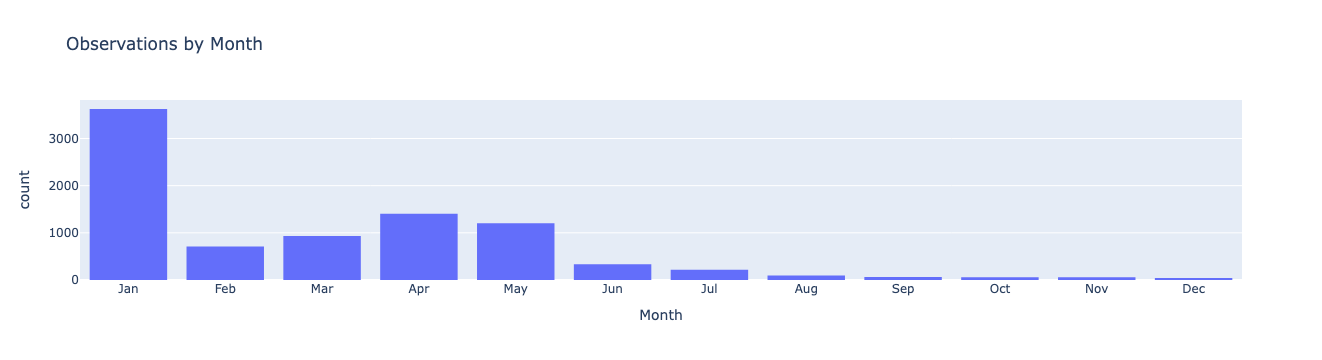

In [5]:
# Convert 'formatted_date_time' to datetime, errors='coerce' will turn bad formats to NaT
flying_squirrels_2000['clean_date'] = pd.to_datetime(flying_squirrels_2000['clean_date'], errors='coerce')

# Check for any NaT values (failed conversions)
print(flying_squirrels_2000['clean_date'].isna().sum())

# Now create 'month_name'
flying_squirrels_2000['month_name'] = flying_squirrels_2000['clean_date'].dt.strftime('%b')



# Create an interactive histogram to show the distribution of fire occurrences over time
fig = px.histogram(flying_squirrels_2000,
                   x='month_name',
                   title='Flying Squirrel Observations by Month (2000-2024)',
                   labels={'year': 'Acquisition Date'},
                   nbins=12,  # Adjust the number of bins for better visualization
                   color_discrete_sequence=['#c08497'])  # Color for the histogram bars

# Update layout for better visualization
fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Observations',
    bargap=0.2,  # Gap between bars
)

fig = px.histogram(flying_squirrels_2000, x='month_name',
                   category_orders={"month_name": ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                                  'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']},
                   title='Observations by Month',
                   labels={'month_name': 'Month', 'count': 'Number of Observations'})

# Show the figure
fig.show()

In [6]:
month_map = {
    "Jan": "January",
    "Feb": "February",
    "Mar": "March",
    "Apr": "April",
    "May": "May",
    "Jun": "June",
    "Jul": "July",
    "Aug": "August",
    "Sep": "September",
    "Oct": "October",
    "Nov": "November",
    "Dec": "December"
}
flying_squirrels_2000["month_name_full"] = (
    flying_squirrels_2000["month_name"].map(month_map)
)

flying_squirrels_2000

,taxonomic_order,formatted_taxon_name,abundance_verbatim,formatted_date_time,country,bio_province_interpreted,locality,collection_name,team,year,geometry,clean_date_str,clean_date,date,Observation date,month,month_name,month_name_full
1239,64441,Siberian Flying Squirrel — Pteromys volans,9,2000-01-01,Suomi,"Etelä-Häme (EH), Etelä-Karjala (EK), Etelä-Sav...",NaN,Wildlife triangle,NaN,2000,POINT (26.54583 60.65919),2000-01-01,2000-01-01,01.01.2000,01.01.2000,1,Jan,January
1240,64441,Siberian Flying Squirrel — Pteromys volans,5,2000-01-01,Suomi,"Etelä-Häme (EH), Uusimaa (U)",NaN,Wildlife triangle,NaN,2000,POINT (25.63133 60.65297),2000-01-01,2000-01-01,01.01.2000,01.01.2000,1,Jan,January
1241,64441,Siberian Flying Squirrel — Pteromys volans,11,2000-01-01,Suomi,"Etelä-Häme (EH), Uusimaa (U), Varsinais-Suomi (V)",NaN,Wildlife triangle,NaN,2000,POINT (24.71744 60.64051),2000-01-01,2000-01-01,01.01.2000,01.01.2000,1,Jan,January
1242,64441,Siberian Flying Squirrel — Pteromys volans,4,2000-01-01,Suomi,Uusimaa (U),NaN,Wildlife triangle,NaN,2000,POINT (25.65002 60.20418),2000-01-01,2000-01-01,01.01.2000,01.01.2000,1,Jan,January
1243,64441,Siberian Flying Squirrel — Pteromys volans,4,2000-01-01,Suomi,"Uusimaa (U), Varsinais-Suomi (V)",NaN,Wildlife triangle,NaN,2000,POINT (23.84819 60.17359),2000-01-01,2000-01-01,01.01.2000,01.01.2000,1,Jan,January
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9969,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-13 [12:07-12:07],Suomi,Uusimaa (U),NaN,"Lajitietokeskus/FinBIF - Notebook, general obs...",Otso Häärä,2024,POINT (24.93557 60.29196),2024-03-13,2024-03-13,13.03.2024,13.03.2024,3,Mar,March
9970,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-20,Suomi,Uusimaa (U),NaN,Löydös Open Finnish Observation Database,Kristiina Boström-Förström,2024,POINT (22.97703 59.77408),2024-03-20,2024-03-20,20.03.2024,20.03.2024,3,Mar,March
9971,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-20,Suomi,Uusimaa (U),NaN,Löydös Open Finnish Observation Database,kristiina boström-förström,2024,POINT (22.97703 59.77408),2024-03-20,2024-03-20,20.03.2024,20.03.2024,3,Mar,March
9972,64441,Siberian Flying Squirrel — Pteromys volans,1,2024-03-20,Suomi,Uusimaa (U),"Eläintarhan koirapuisto, Töölö",Löydös Open Finnish Observation Database,NaN,2024,POINT (25.01864 60.11016),2024-03-20,2024-03-20,20.03.2024,20.03.2024,3,Mar,March


Number of invalid dates: 3475


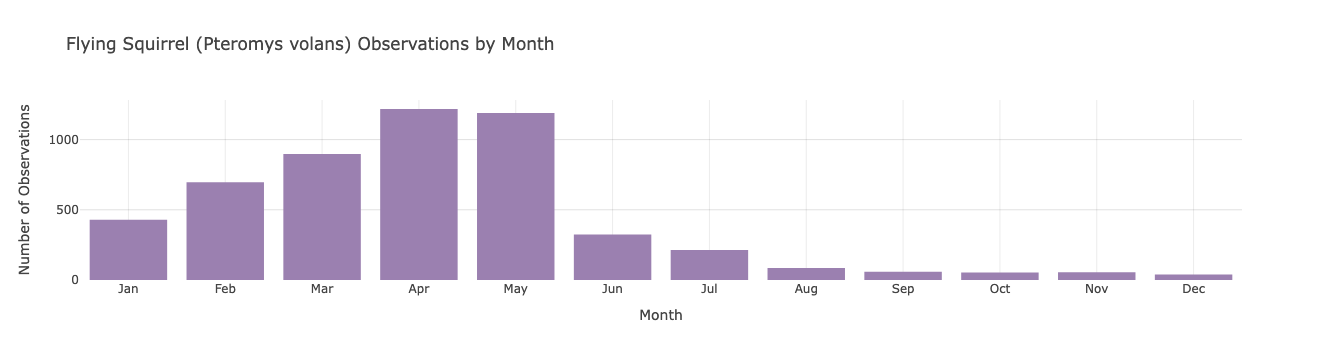

In [7]:
# Convert 'formatted_date_time' to datetime, coercing errors to NaT
flying_squirrels_2000['formatted_date_time'] = pd.to_datetime(
    flying_squirrels_2000['formatted_date_time'], errors='coerce'
)

# Check how many datetime conversions failed
num_invalid_dates = flying_squirrels_2000['formatted_date_time'].isna().sum()
print(f"Number of invalid dates: {num_invalid_dates}")

# Create 'month_name' column with abbreviated month names
flying_squirrels_2000['month_name'] = flying_squirrels_2000['formatted_date_time'].dt.strftime('%b')

# Create an interactive histogram showing observations by month with ordered categories
fig = px.histogram(
    flying_squirrels_2000,
    x='month_name',
    category_orders={
        "month_name": ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    },
    title='Flying Squirrel (Pteromys volans) Observations by Month',
    labels={'month_name': 'Month', 'count': 'Number of Observations'},
    color_discrete_sequence=['#9b80b0'],
    nbins=12
)

# Update layout for better visuals
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis_title="Month",
    yaxis_title="Number of Observations",
    bargap=0.2,
    font=dict(color="#444444"),
        xaxis=dict(
        showgrid=True,
        gridcolor="rgba(0,0,0,0.08)"
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor="rgba(0,0,0,0.12)"
        
    )
)

fig.update_traces(
    hovertemplate=
    "Month: %{x}<br>" +
    "Observations: %{y}<extra></extra>"
)
# Show the figure
fig.show()

fig.write_html("flying_squirrels_noncarto.html")